In [41]:
from pathlib import Path
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

In [42]:
cwd = Path.cwd()
root = cwd if (cwd / "data").exists() else cwd.parent

candidates = [
    root / "data" / "mind@work" / "mental_health_dataset" / "Cleaned_remote_work.csv",
    root / "data" / "mind@work" / "mental heath dataset" / "Cleaned_remote_work.csv",  # legacy typo
]

data_file = next((p for p in candidates if p.exists()), None)
assert data_file is not None, f"Dataset not found. Checked:\n- " + "\n- ".join(map(str, candidates))
data_file

PosixPath('/Users/huongle/Documents/GitHub/Mind_At_Work_Website/data/mind@work/mental_health_dataset/Cleaned_remote_work.csv')

In [43]:
df = pd.read_csv(data_file)
print(f"rows: {len(df):,} | cols: {df.shape[1]}")
df.head()

rows: 5,000 | cols: 19


,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,No Activity,Poor,North America
3,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,No Activity,Poor,Europe
4,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,No Condition,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [44]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Age                                5000 non-null   int64   
 1   Gender                             5000 non-null   category
 2   Job_Role                           5000 non-null   category
 3   Industry                           5000 non-null   category
 4   Years_of_Experience                5000 non-null   int64   
 5   Work_Location                      5000 non-null   category
 6   Hours_Worked_Per_Week              5000 non-null   int64   
 7   Number_of_Virtual_Meetings         5000 non-null   int64   
 8   Work_Life_Balance_Rating           5000 non-null   int64   
 9   Stress_Level                       5000 non-null   category
 10  Mental_Health_Condition            5000 non-null   category
 11  Access_to_Mental_Health_Resources  5000 non

# 1. Train/Valid sepearatiom

In [45]:
from sklearn.model_selection import train_test_split

TARGET = "Mental_Health_Condition"   # adjust if needed

X = df.drop(columns=[TARGET])
y = df[TARGET].astype("category")  # make sure target is categorical

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_valid:", X_valid.shape)
print("y_train:", y_train.shape, "y_valid:", y_valid.shape)

# Class distribution check
print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nValid distribution:\n", y_valid.value_counts(normalize=True))

X_train: (4000, 18) X_valid: (1000, 18)
y_train: (4000,) y_valid: (1000,)

Train distribution:
 Mental_Health_Condition
Burnout         0.25600
Anxiety         0.25550
Depression      0.24925
No Condition    0.23925
Name: proportion, dtype: float64

Valid distribution:
 Mental_Health_Condition
Anxiety         0.256
Burnout         0.256
Depression      0.249
No Condition    0.239
Name: proportion, dtype: float64


# 2. Buidling frame to apply to all model later

## Cell 1: Model dictionary

In [46]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [47]:
def make_models(random_state=42):
    return {
        "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=random_state),
        "GradientBoost": GradientBoostingClassifier(random_state=random_state),
        "SVC": SVC(probability=True, class_weight="balanced", random_state=random_state),
        "KNN": KNeighborsClassifier(n_neighbors=7),
    }

In [48]:
models = make_models(random_state=42)

## Cell 3: Encoding helper

In [49]:
def encode_dummies(X_train, X_valid, cat_cols=None, num_cols=None):
    if cat_cols is None:
        cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    if num_cols is None:
        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    # ensure numeric
    for c in num_cols:
        X_train[c] = pd.to_numeric(X_train[c], errors="coerce")
        X_valid[c] = pd.to_numeric(X_valid[c], errors="coerce")

    # fill missing numerics
    X_train[num_cols] = X_train[num_cols].fillna(0)
    X_valid[num_cols] = X_valid[num_cols].fillna(0)

    # one-hot categoricals
    Xtr = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
    Xva = pd.get_dummies(X_valid, columns=cat_cols, drop_first=False)
    Xva = Xva.reindex(columns=Xtr.columns, fill_value=0)
    return Xtr, Xva

## Cell 4: Validation evaluation

In [50]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def valid_table_per_class(models, Xtr, ytr, Xva, yva):
    rows = []
    for name, clf in models.items():
        clf.fit(Xtr, ytr)
        y_pred = clf.predict(Xva)

        # per-class metrics (labels order = [0, 1])
        p, r, f1, _ = precision_recall_fscore_support(
            yva, y_pred, labels=[0, 1], zero_division=0
        )
        acc = accuracy_score(yva, y_pred)

        rows.append({
            "model": name,
            "acc": acc,
            "prec_0": p[0], "rec_0": r[0], "f1_0": f1[0],   # NoProblem
            "prec_1": p[1], "rec_1": r[1], "f1_1": f1[1],   # Problem
            "f1_macro": (f1[0] + f1[1]) / 2.0
        })

    return (pd.DataFrame(rows)
              .set_index("model")
              .round(4)
              .sort_values("f1_macro", ascending=False))


## Cell 5: Cross-Validation

In [51]:
def crossval_table_split(models, X, y, folds=5, seed=42):
    cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)
    rows0, rows1, rows_macro = [], [], []
    binary = len(np.unique(y)) == 2

    for name, clf in models.items():
        accs = []
        p0s, r0s, f10s = [], [], []
        p1s, r1s, f11s = [], [], []
        p_mac, r_mac, f1_mac = [], [], []
        aucs, ap_aucs = [], []

        for tr_idx, va_idx in cv.split(X, y):
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_va)

            # per-class metrics
            p, r, f1, _ = precision_recall_fscore_support(
                y_va, y_pred, labels=[0, 1], zero_division=0
            )
            p0s.append(p[0]); r0s.append(r[0]); f10s.append(f1[0])
            p1s.append(p[1]); r1s.append(r[1]); f11s.append(f1[1])
            p_mac.append((p[0]+p[1])/2); r_mac.append((r[0]+r[1])/2); f1_mac.append((f1[0]+f1[1])/2)

            accs.append(accuracy_score(y_va, y_pred))

            if hasattr(clf, "predict_proba") or hasattr(clf, "decision_function"):
                try:
                    if hasattr(clf, "predict_proba"):
                        scores = clf.predict_proba(X_va)[:, 1]
                    else:
                        scores = clf.decision_function(X_va)
                    aucs.append(roc_auc_score(y_va, scores))
                    ap_aucs.append(average_precision_score(y_va, scores))
                except:
                    pass

        rows0.append({
            "model": name,
            "Prec_0_mean": np.mean(p0s), "Prec_0_std": np.std(p0s),
            "Rec_0_mean":  np.mean(r0s), "Rec_0_std":  np.std(r0s),
            "F1_0_mean":   np.mean(f10s),"F1_0_std":   np.std(f10s),
        })

        rows1.append({
            "model": name,
            "Prec_1_mean": np.mean(p1s), "Prec_1_std": np.std(p1s),
            "Rec_1_mean":  np.mean(r1s), "Rec_1_std":  np.std(r1s),
            "F1_1_mean":   np.mean(f11s),"F1_1_std":   np.std(f11s),
        })

        rows_macro.append({
            "model": name,
            "Acc_mean": np.mean(accs), "Acc_std": np.std(accs),
            "Prec_macro_mean": np.mean(p_mac), "Prec_macro_std": np.std(p_mac),
            "Rec_macro_mean":  np.mean(r_mac), "Rec_macro_std":  np.std(r_mac),
            "F1_macro_mean":   np.mean(f1_mac),"F1_macro_std":   np.std(f1_mac),
            "ROC_AUC_mean": np.mean(aucs) if aucs else np.nan,
            "ROC_AUC_std":  np.std(aucs)  if aucs else np.nan,
            "PR_AUC_mean":  np.mean(ap_aucs) if ap_aucs else np.nan,
            "PR_AUC_std":   np.std(ap_aucs)  if ap_aucs else np.nan,
        })

    df0 = pd.DataFrame(rows0).set_index("model").round(4).sort_values("F1_0_mean", ascending=False)
    df1 = pd.DataFrame(rows1).set_index("model").round(4).sort_values("F1_1_mean", ascending=False)
    df_macro = pd.DataFrame(rows_macro).set_index("model").round(4).sort_values("F1_macro_mean", ascending=False)

    return df0, df1, df_macro


In [52]:
from IPython.display import HTML, display

def show_scrollable(df, height=420):
    html = df.to_html(classes="wide-table")
    styled = f"""
    <div style="max-height:{height}px; overflow-y:auto; border:1px solid #ddd; padding:6px;">
        {html}
    </div>
    """
    display(HTML(styled))

# 3. Predicting Mental Health Condition binary

- Set label + pick features + split

In [53]:
from sklearn.model_selection import train_test_split

# 1) Binary label: 1 = has problem, 0 = no problem
df["Mental_Problem"] = (df["Mental_Health_Condition"] != "No Condition").astype(int)

# 2) Feature subset
FEATURES = ["Job_Role","Work_Location","Hours_Worked_Per_Week","Number_of_Virtual_Meetings","Physical_Activity"]
TARGET = "Mental_Problem"

X = df[FEATURES].copy()
y = df[TARGET].copy()

# 3) Stratified split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

- Encode (uses Cell 3 function)

In [54]:
Xtr, Xva = encode_dummies(X_train.copy(), X_valid.copy())

Models + 5-fold CV table (uses Cells 2 & 5)

In [55]:
df_class0, df_class1, df_macro = crossval_table_split(models, Xtr, y_train, folds=5, seed=42)

print("=== Class 0 (NoProblem) ===")
display(df_class0)

print("\n=== Class 1 (Problem) ===")
display(df_class1)

print("\n=== Macro + AUCs ===")
display(df_macro)

=== Class 0 (NoProblem) ===


,Prec_0_mean,Prec_0_std,Rec_0_mean,Rec_0_std,F1_0_mean,F1_0_std
model,,,,,,
LogReg,0.2574,0.0134,0.4524,0.0425,0.3271,0.0149
SVC,0.2426,0.0193,0.4617,0.1462,0.3098,0.0376
RandomForest,0.2370,0.0566,0.1232,0.0350,0.1620,0.0435
KNN,0.2381,0.0465,0.0658,0.0085,0.1028,0.0140
GradientBoost,0.2005,0.1104,0.0073,0.0053,0.0141,0.0101



=== Class 1 (Problem) ===


,Prec_1_mean,Prec_1_std,Rec_1_mean,Rec_1_std,F1_1_mean,F1_1_std
model,,,,,,
GradientBoost,0.7607,0.0011,0.9924,0.0025,0.8613,0.0004
KNN,0.7602,0.0041,0.9316,0.0139,0.8372,0.0080
RandomForest,0.7610,0.0070,0.8774,0.0036,0.8150,0.0049
LogReg,0.7730,0.0094,0.5875,0.0519,0.6665,0.0355
SVC,0.7614,0.0136,0.5415,0.1516,0.6209,0.1068



=== Macro + AUCs ===


,Acc_mean,Acc_std,Prec_macro_mean,Prec_macro_std,Rec_macro_mean,Rec_macro_std,F1_macro_mean,F1_macro_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
model,,,,,,,,,,,,
LogReg,0.5552,0.0317,0.5152,0.0113,0.5200,0.0148,0.4968,0.0188,0.5382,0.0146,0.7868,0.0113
RandomForest,0.6970,0.0092,0.4990,0.0318,0.5003,0.0181,0.4885,0.0240,0.5194,0.0126,0.7782,0.0088
KNN,0.7245,0.0118,0.4992,0.0253,0.4987,0.0094,0.4700,0.0101,0.5189,0.0105,0.7718,0.0031
SVC,0.5225,0.0824,0.5020,0.0164,0.5016,0.0213,0.4654,0.0407,0.4828,0.0120,0.7475,0.0077
GradientBoost,0.7568,0.0006,0.4806,0.0557,0.4999,0.0017,0.4377,0.0050,0.5495,0.0222,0.7951,0.0089


- GradientBoost: excellent on majority class, top PR-AUC, stable; but nearly ignores minority.
- LogReg / SVC: weak on majority, but best chance for minority detection (recall ~0.45).
- RandomForest / KNN: middle ground — decent majority, but almost useless on minority.

In [56]:
valid_results = valid_table_per_class(models, Xtr, y_train, Xva, y_valid)
print(valid_results)

                 acc  prec_0   rec_0    f1_0  prec_1   rec_1    f1_1  f1_macro
model                                                                         
LogReg         0.551  0.2500  0.4393  0.3187  0.7690  0.5861  0.6652    0.4919
SVC            0.585  0.2105  0.2678  0.2357  0.7486  0.6846  0.7152    0.4754
RandomForest   0.688  0.2033  0.1046  0.1381  0.7560  0.8712  0.8095    0.4738
KNN            0.732  0.2364  0.0544  0.0884  0.7608  0.9448  0.8429    0.4657
GradientBoost  0.760  0.3333  0.0042  0.0083  0.7613  0.9974  0.8635    0.4359


## Cell 6: Models_Weighted

In [57]:
models_weighted = {
    "LogReg_w": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest_w": RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=42),
    "SVC_w": SVC(probability=True, class_weight="balanced", random_state=42),
    # GradientBoosting + KNN don’t directly support class_weight, keep them unweighted for comparison
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

In [58]:
cv_class0, cv_class1, cv_macro = crossval_table_split(models_weighted, Xtr, y_train, folds=5)
display(cv_class0); display(cv_class1); display(cv_macro)

,Prec_0_mean,Prec_0_std,Rec_0_mean,Rec_0_std,F1_0_mean,F1_0_std
model,,,,,,
LogReg_w,0.2574,0.0134,0.4524,0.0425,0.3271,0.0149
SVC_w,0.2426,0.0193,0.4617,0.1462,0.3098,0.0376
RandomForest_w,0.2299,0.0481,0.1222,0.0315,0.1594,0.0383
KNN,0.2381,0.0465,0.0658,0.0085,0.1028,0.0140
GradientBoost,0.2005,0.1104,0.0073,0.0053,0.0141,0.0101


,Prec_1_mean,Prec_1_std,Rec_1_mean,Rec_1_std,F1_1_mean,F1_1_std
model,,,,,,
GradientBoost,0.7607,0.0011,0.9924,0.0025,0.8613,0.0004
KNN,0.7602,0.0041,0.9316,0.0139,0.8372,0.0080
RandomForest_w,0.7598,0.0060,0.8732,0.0064,0.8125,0.0045
LogReg_w,0.7730,0.0094,0.5875,0.0519,0.6665,0.0355
SVC_w,0.7614,0.0136,0.5415,0.1516,0.6209,0.1068


,Acc_mean,Acc_std,Prec_macro_mean,Prec_macro_std,Rec_macro_mean,Rec_macro_std,F1_macro_mean,F1_macro_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
model,,,,,,,,,,,,
LogReg_w,0.5552,0.0317,0.5152,0.0113,0.5200,0.0148,0.4968,0.0188,0.5382,0.0146,0.7868,0.0113
RandomForest_w,0.6935,0.0080,0.4949,0.0270,0.4977,0.0156,0.4860,0.0207,0.5180,0.0147,0.7752,0.0082
KNN,0.7245,0.0118,0.4992,0.0253,0.4987,0.0094,0.4700,0.0101,0.5189,0.0105,0.7718,0.0031
SVC_w,0.5225,0.0824,0.5020,0.0164,0.5016,0.0213,0.4654,0.0407,0.4828,0.0120,0.7475,0.0077
GradientBoost,0.7568,0.0006,0.4806,0.0557,0.4999,0.0017,0.4377,0.0050,0.5495,0.0222,0.7951,0.0089


In [59]:
valid_results_w = valid_table_per_class(models_weighted, Xtr, y_train, Xva, y_valid)
print(valid_results_w)

                  acc  prec_0   rec_0    f1_0  prec_1   rec_1    f1_1  \
model                                                                   
LogReg_w        0.551  0.2500  0.4393  0.3187  0.7690  0.5861  0.6652   
RandomForest_w  0.685  0.2121  0.1172  0.1509  0.7569  0.8633  0.8066   
SVC_w           0.585  0.2105  0.2678  0.2357  0.7486  0.6846  0.7152   
KNN             0.732  0.2364  0.0544  0.0884  0.7608  0.9448  0.8429   
GradientBoost   0.760  0.3333  0.0042  0.0083  0.7613  0.9974  0.8635   

                f1_macro  
model                     
LogReg_w          0.4919  
RandomForest_w    0.4788  
SVC_w             0.4754  
KNN               0.4657  
GradientBoost     0.4359  


## Cell 7: SMOTE

In [60]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

def build_models_with_smote_dict(model_dict, random_state=42, **smote_kwargs):
    return {
        f"{name}_SMOTE": ImbPipeline([
            ("smote", SMOTE(random_state=random_state, **smote_kwargs)),
            ("clf", clf)
        ])
        for name, clf in model_dict.items()
    }

# SMOTE + (your) models
models_smote_unw = build_models_with_smote_dict(models, random_state=42)          # your make_models()
models_smote_w   = build_models_with_smote_dict(models_weighted, random_state=42) # your models_weighted

In [61]:
print("=== SMOTE + (models) ===")
cv0_u, cv1_u, cvm_u = crossval_table_split(models_smote_unw, Xtr, y_train, folds=5, seed=42)
display(cv0_u); display(cv1_u); display(cvm_u)


=== SMOTE + (models) ===


,Prec_0_mean,Prec_0_std,Rec_0_mean,Rec_0_std,F1_0_mean,F1_0_std
model,,,,,,
KNN_SMOTE,0.2543,0.0106,0.5381,0.0201,0.3452,0.0127
SVC_SMOTE,0.2374,0.0203,0.3614,0.2402,0.2546,0.0783
RandomForest_SMOTE,0.2389,0.0447,0.1650,0.0403,0.1948,0.0427
GradientBoost_SMOTE,0.2891,0.0624,0.0293,0.0161,0.0523,0.0265
LogReg_SMOTE,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,Prec_1_mean,Prec_1_std,Rec_1_mean,Rec_1_std,F1_1_mean,F1_1_std
model,,,,,,
LogReg_SMOTE,0.7608,0.0006,1.0000,0.0000,0.8641,0.0004
GradientBoost_SMOTE,0.7621,0.0023,0.9777,0.0092,0.8565,0.0031
RandomForest_SMOTE,0.7613,0.0078,0.8370,0.0142,0.7973,0.0078
SVC_SMOTE,0.7550,0.0128,0.6296,0.2484,0.6568,0.1782
KNN_SMOTE,0.7758,0.0097,0.5031,0.0227,0.6102,0.0190


,Acc_mean,Acc_std,Prec_macro_mean,Prec_macro_std,Rec_macro_mean,Rec_macro_std,F1_macro_mean,F1_macro_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
model,,,,,,,,,,,,
RandomForest_SMOTE,0.6762,0.0114,0.5001,0.0262,0.5010,0.0187,0.4960,0.0229,0.5149,0.0126,0.7759,0.0056
KNN_SMOTE,0.5115,0.0171,0.5150,0.0101,0.5206,0.0139,0.4777,0.0141,0.5261,0.0086,0.7777,0.0031
SVC_SMOTE,0.5655,0.1319,0.4962,0.0146,0.4955,0.0141,0.4557,0.0566,0.4912,0.0075,0.7582,0.0083
GradientBoost_SMOTE,0.7508,0.0043,0.5256,0.0322,0.5035,0.0049,0.4544,0.0125,0.5363,0.0138,0.7851,0.0059
LogReg_SMOTE,0.7608,0.0006,0.3804,0.0003,0.5000,0.0000,0.4321,0.0002,0.5295,0.0090,0.7800,0.0061


In [62]:
print("\n=== SMOTE + (models_weighted) ===")
cv0_w, cv1_w, cvm_w = crossval_table_split(models_smote_w, Xtr, y_train, folds=5, seed=42)
display(cv0_w); display(cv1_w); display(cvm_w)


=== SMOTE + (models_weighted) ===


,Prec_0_mean,Prec_0_std,Rec_0_mean,Rec_0_std,F1_0_mean,F1_0_std
model,,,,,,
KNN_SMOTE,0.2543,0.0106,0.5381,0.0201,0.3452,0.0127
SVC_w_SMOTE,0.2374,0.0203,0.3614,0.2402,0.2546,0.0783
RandomForest_w_SMOTE,0.2442,0.0396,0.1640,0.0373,0.1958,0.0390
GradientBoost_SMOTE,0.2891,0.0624,0.0293,0.0161,0.0523,0.0265
LogReg_w_SMOTE,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,Prec_1_mean,Prec_1_std,Rec_1_mean,Rec_1_std,F1_1_mean,F1_1_std
model,,,,,,
LogReg_w_SMOTE,0.7608,0.0006,1.0000,0.0000,0.8641,0.0004
GradientBoost_SMOTE,0.7621,0.0023,0.9777,0.0092,0.8565,0.0031
RandomForest_w_SMOTE,0.7623,0.0065,0.8426,0.0121,0.8004,0.0058
SVC_w_SMOTE,0.7550,0.0128,0.6296,0.2484,0.6568,0.1782
KNN_SMOTE,0.7758,0.0097,0.5031,0.0227,0.6102,0.0190


,Acc_mean,Acc_std,Prec_macro_mean,Prec_macro_std,Rec_macro_mean,Rec_macro_std,F1_macro_mean,F1_macro_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
model,,,,,,,,,,,,
RandomForest_w_SMOTE,0.6802,0.0085,0.5033,0.0231,0.5033,0.0161,0.4981,0.0203,0.5162,0.0127,0.7772,0.0096
KNN_SMOTE,0.5115,0.0171,0.5150,0.0101,0.5206,0.0139,0.4777,0.0141,0.5261,0.0086,0.7777,0.0031
SVC_w_SMOTE,0.5655,0.1319,0.4962,0.0146,0.4955,0.0141,0.4557,0.0566,0.4912,0.0075,0.7582,0.0083
GradientBoost_SMOTE,0.7508,0.0043,0.5256,0.0322,0.5035,0.0049,0.4544,0.0125,0.5363,0.0138,0.7851,0.0059
LogReg_w_SMOTE,0.7608,0.0006,0.3804,0.0003,0.5000,0.0000,0.4321,0.0002,0.5295,0.0090,0.7800,0.0061


## Cell 8: Thresold

In [63]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score, average_precision_score

def _scores_from_model(clf, X):
    """Return a 1D score for class 1 for thresholding.
       Uses predict_proba if available; else decision_function scaled to [0,1]."""
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    elif hasattr(clf, "decision_function"):
        s = clf.decision_function(X).astype(float)
        # min-max scale to [0,1] to enable a common threshold grid
        s_min, s_max = s.min(), s.max()
        return (s - s_min) / (s_max - s_min + 1e-12)
    else:
        raise ValueError(f"{type(clf).__name__} has neither predict_proba nor decision_function.")

def sweep_thresholds(clf, Xtr, ytr, Xva, yva, thresholds=None):
    """Fit clf, get validation scores, evaluate metrics over threshold grid.
       Returns (df_thresholds_sorted, best_row_by_macroF1)."""
    if thresholds is None:
        thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00

    clf.fit(Xtr, ytr)
    s_val = _scores_from_model(clf, Xva)

    rows = []
    for t in thresholds:
        y_pred = (s_val >= t).astype(int)

        # per-class metrics (labels [0,1] -> NoProblem, Problem)
        p, r, f1, _ = precision_recall_fscore_support(yva, y_pred, labels=[0,1], zero_division=0)
        acc = accuracy_score(yva, y_pred)
        row = {
            "thr": t,
            "acc": acc,
            "prec_0": p[0], "rec_0": r[0], "f1_0": f1[0],
            "prec_1": p[1], "rec_1": r[1], "f1_1": f1[1],
            "prec_macro": (p[0]+p[1])/2, "rec_macro": (r[0]+r[1])/2, "f1_macro": (f1[0]+f1[1])/2,
        }
        rows.append(row)

    df = pd.DataFrame(rows).sort_values("thr").reset_index(drop=True)
    best = df.loc[df["f1_macro"].idxmax()]  # choose the threshold that maximizes macro-F1
    return df, best


In [64]:
def tune_thresholds_for_models(models, Xtr, ytr, Xva, yva, thresholds=None):
    """Run sweep for each model dict; return dict of per-model tables and a summary of best thresholds."""
    per_model_tables = {}
    summary_rows = []
    for name, clf in models.items():
        try:
            df_t, best = sweep_thresholds(clf, Xtr, ytr, Xva, yva, thresholds)
            per_model_tables[name] = df_t
            summary_rows.append({
                "model": name,
                "best_thr": float(best["thr"]),
                "f1_macro": float(best["f1_macro"]),
                "f1_0": float(best["f1_0"]), "rec_0": float(best["rec_0"]), "prec_0": float(best["prec_0"]),
                "f1_1": float(best["f1_1"]), "rec_1": float(best["rec_1"]), "prec_1": float(best["prec_1"]),
                "acc": float(best["acc"]),
            })
        except Exception as e:
            summary_rows.append({"model": name, "best_thr": np.nan, "f1_macro": np.nan, "error": str(e)})
    summary = pd.DataFrame(summary_rows).set_index("model").sort_values("f1_macro", ascending=False).round(4)
    return per_model_tables, summary


In [65]:
# example: pick which family to tune
# models_to_tune = models                # base
# models_to_tune = models_weighted       # weighted
# models_to_tune = models_smote_unw      # SMOTE + base
models_to_tune = models_smote_w          # SMOTE + weighted (for instance)

per_model, thr_summary = tune_thresholds_for_models(models_to_tune, Xtr, y_train, Xva, y_valid)
print(thr_summary)


                      best_thr  f1_macro    f1_0   rec_0  prec_0    f1_1  \
model                                                                      
LogReg_w_SMOTE            0.71    0.5214  0.2811  0.2929  0.2703  0.7617   
SVC_w_SMOTE               0.43    0.5145  0.2353  0.2092  0.2688  0.7937   
KNN_SMOTE                 0.15    0.5092  0.2000  0.1548  0.2824  0.8184   
GradientBoost_SMOTE       0.61    0.5033  0.2555  0.2678  0.2443  0.7512   
RandomForest_w_SMOTE      0.50    0.4962  0.1919  0.1590  0.2420  0.8005   

                       rec_1  prec_1    acc  
model                                        
LogReg_w_SMOTE        0.7516  0.7719  0.642  
SVC_w_SMOTE           0.8213  0.7678  0.675  
KNN_SMOTE             0.8765  0.7675  0.704  
GradientBoost_SMOTE   0.7398  0.7629  0.627  
RandomForest_w_SMOTE  0.8436  0.7616  0.680  


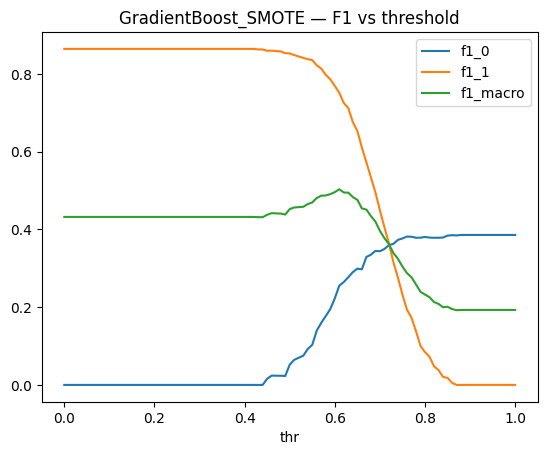

In [66]:
per_model["GradientBoost_SMOTE"].head()         # first rows
per_model["GradientBoost_SMOTE"].plot(x="thr", y=["f1_0","f1_1","f1_macro"], title="GradientBoost_SMOTE — F1 vs threshold");

# 3. Feature enginering

In [67]:

# make bins you can tweak later
HOURS_BINS   = [0, 20, 35, 45, 55, 1_000]
HOURS_LABELS = ["≤20", "21–35", "36–45", "46–55", "56+"]

MEET_BINS    = [0, 2, 5, 9, 1000]
MEET_LABELS  = ["0–1", "2–4", "5–8", "9+"]

def add_bins(X_train, X_valid):
    Xtr = X_train.copy()
    Xva = X_valid.copy()

    # ensure numeric before binning
    Xtr["Hours_Worked_Per_Week"]        = pd.to_numeric(Xtr["Hours_Worked_Per_Week"], errors="coerce")
    Xva["Hours_Worked_Per_Week"]        = pd.to_numeric(Xva["Hours_Worked_Per_Week"], errors="coerce")
    Xtr["Number_of_Virtual_Meetings"]   = pd.to_numeric(Xtr["Number_of_Virtual_Meetings"], errors="coerce")
    Xva["Number_of_Virtual_Meetings"]   = pd.to_numeric(Xva["Number_of_Virtual_Meetings"], errors="coerce")

    # bin with same edges for train/valid
    Xtr["Hours_Bin"] = pd.cut(Xtr["Hours_Worked_Per_Week"], HOURS_BINS, labels=HOURS_LABELS, right=False)
    Xva["Hours_Bin"] = pd.cut(Xva["Hours_Worked_Per_Week"], HOURS_BINS, labels=HOURS_LABELS, right=False)

    Xtr["Meetings_Bin"] = pd.cut(Xtr["Number_of_Virtual_Meetings"], MEET_BINS, labels=MEET_LABELS, right=False)
    Xva["Meetings_Bin"] = pd.cut(Xva["Number_of_Virtual_Meetings"], MEET_BINS, labels=MEET_LABELS, right=False)

    # optional: drop originals once binned (comment out if you want both)
    Xtr = Xtr.drop(columns=["Hours_Worked_Per_Week", "Number_of_Virtual_Meetings"])
    Xva = Xva.drop(columns=["Hours_Worked_Per_Week", "Number_of_Virtual_Meetings"])

    return Xtr, Xva

# apply
X_train_b, X_valid_b = add_bins(X_train, X_valid)

# quick sanity check (optional)
print("Hours_Bin train:\n", X_train_b["Hours_Bin"].value_counts(dropna=False))
print("\nMeetings_Bin train:\n", X_train_b["Meetings_Bin"].value_counts(dropna=False))


Hours_Bin train:
 Hours_Bin
21–35    1545
36–45     962
46–55     941
56+       552
≤20         0
Name: count, dtype: int64

Meetings_Bin train:
 Meetings_Bin
9+     1767
5–8    1026
2–4     737
0–1     470
Name: count, dtype: int64


In [68]:
# Use your encode_dummies() from Cell 3
cat_cols = ["Job_Role", "Work_Location", "Physical_Activity", "Hours_Bin", "Meetings_Bin"]
num_cols = []  # we dropped numeric originals above

Xtr, Xva = encode_dummies(X_train_b.copy(), X_valid_b.copy(), cat_cols=cat_cols, num_cols=num_cols)
print("Encoded shapes:", Xtr.shape, Xva.shape)

Encoded shapes: (4000, 22) (1000, 22)


In [69]:
cv_results = crossval_table_split(models, Xtr, y_train, folds=5, seed=42)
print(cv_results)

(               Prec_0_mean  Prec_0_std  Rec_0_mean  Rec_0_std  F1_0_mean  \
model                                                                      
LogReg              0.2611      0.0135      0.4722     0.0377     0.3355   
SVC                 0.2577      0.0200      0.4702     0.0543     0.3322   
RandomForest        0.2627      0.0141      0.3417     0.0300     0.2969   
KNN                 0.2394      0.0612      0.0606     0.0112     0.0965   
GradientBoost       0.2500      0.2472      0.0042     0.0039     0.0082   

               F1_0_std  
model                    
LogReg           0.0140  
SVC              0.0269  
RandomForest     0.0198  
KNN              0.0189  
GradientBoost    0.0077  ,                Prec_1_mean  Prec_1_std  Rec_1_mean  Rec_1_std  F1_1_mean  \
model                                                                      
GradientBoost       0.7611      0.0006      0.9977     0.0017     0.8635   
KNN                 0.7604      0.0037      0.9379     

In [70]:
cv_results = crossval_table_split(models_weighted, Xtr, y_train, folds=5, seed=42)
print(cv_results)

(                Prec_0_mean  Prec_0_std  Rec_0_mean  Rec_0_std  F1_0_mean  \
model                                                                       
LogReg_w             0.2611      0.0135      0.4722     0.0377     0.3355   
SVC_w                0.2577      0.0200      0.4702     0.0543     0.3322   
RandomForest_w       0.2649      0.0166      0.3417     0.0324     0.2982   
KNN                  0.2394      0.0612      0.0606     0.0112     0.0965   
GradientBoost        0.2500      0.2472      0.0042     0.0039     0.0082   

                F1_0_std  
model                     
LogReg_w          0.0140  
SVC_w             0.0269  
RandomForest_w    0.0219  
KNN               0.0189  
GradientBoost     0.0077  ,                 Prec_1_mean  Prec_1_std  Rec_1_mean  Rec_1_std  F1_1_mean  \
model                                                                       
GradientBoost        0.7611      0.0006      0.9977     0.0017     0.8635   
KNN                  0.7604      0.003

# 4. Ordinal encoding

In [71]:
from sklearn.preprocessing import OrdinalEncoder

# Choose the ordinal columns
ord_cols = ["Hours_Bin", "Meetings_Bin", "Physical_Activity"]
cat_cols = ["Job_Role", "Work_Location"]  # still nominal

# Fit encoder only on train
ord_enc = OrdinalEncoder()
X_train_b[ord_cols] = ord_enc.fit_transform(X_train_b[ord_cols])
X_valid_b[ord_cols] = ord_enc.transform(X_valid_b[ord_cols])

# One-hot for nominal (job role, work location)
Xtr = pd.get_dummies(X_train_b, columns=cat_cols, drop_first=False)
Xva = pd.get_dummies(X_valid_b, columns=cat_cols, drop_first=False)

# Align columns
Xva = Xva.reindex(columns=Xtr.columns, fill_value=0)

print("Shapes:", Xtr.shape, Xva.shape)

Shapes: (4000, 13) (1000, 13)


In [72]:
# CV (gives Class 0 table, Class 1 table, and Macro+AUCs)
cv_c0, cv_c1, cv_macro = crossval_table_split(models, Xtr, y_train, folds=5, seed=42)
display(cv_c0); display(cv_c1); display(cv_macro)

,Prec_0_mean,Prec_0_std,Rec_0_mean,Rec_0_std,F1_0_mean,F1_0_std
model,,,,,,
SVC,0.2647,0.0118,0.4931,0.0624,0.3436,0.0237
LogReg,0.2603,0.0131,0.4691,0.0573,0.3338,0.0213
RandomForest,0.2633,0.0168,0.3427,0.0346,0.2975,0.0226
KNN,0.2136,0.0414,0.0575,0.0058,0.0901,0.0089
GradientBoost,0.3000,0.4000,0.0021,0.0026,0.0041,0.0051


,Prec_1_mean,Prec_1_std,Rec_1_mean,Rec_1_std,F1_1_mean,F1_1_std
model,,,,,,
GradientBoost,0.7610,0.0006,0.9990,0.0013,0.8639,0.0006
KNN,0.7585,0.0026,0.9313,0.0126,0.8361,0.0064
RandomForest,0.7719,0.0075,0.6990,0.0172,0.7335,0.0096
LogReg,0.7769,0.0091,0.5806,0.0493,0.6634,0.0320
SVC,0.7820,0.0100,0.5701,0.0450,0.6583,0.0285


,Acc_mean,Acc_std,Prec_macro_mean,Prec_macro_std,Rec_macro_mean,Rec_macro_std,F1_macro_mean,F1_macro_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
model,,,,,,,,,,,,
RandomForest,0.6138,0.0107,0.5176,0.0121,0.5209,0.0142,0.5155,0.0124,0.5203,0.0164,0.7723,0.0116
SVC,0.5518,0.0220,0.5234,0.0108,0.5316,0.0149,0.5009,0.0121,0.5429,0.0253,0.7821,0.0130
LogReg,0.5540,0.0267,0.5186,0.0110,0.5249,0.0145,0.4986,0.0149,0.5424,0.0150,0.7889,0.0111
KNN,0.7223,0.0095,0.4861,0.0219,0.4944,0.0069,0.4631,0.0066,0.5198,0.0165,0.7702,0.0066
GradientBoost,0.7605,0.0010,0.5305,0.2001,0.5006,0.0015,0.4340,0.0027,0.5449,0.0304,0.7899,0.0139


# 5. Second model dictionary

In [73]:
# Second model zoo: stronger tree/boosting variants
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.experimental import enable_hist_gradient_boosting  # safe import
from sklearn.ensemble import HistGradientBoostingClassifier

def make_models2(random_state=42):
    models2 = {
        # Very strong, fast, supports sample_weight
        "HistGB": HistGradientBoostingClassifier(
            learning_rate=0.08, max_iter=500, max_depth=None,
            l2_regularization=0.0, random_state=random_state
        ),
        # Robust non-boosted ensemble, good baseline, class_weight supported
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=600, max_depth=None, min_samples_split=2,
            class_weight="balanced", n_jobs=-1, random_state=random_state
        ),
    }

    # Optional: XGBoost (if installed)
    try:
        from xgboost import XGBClassifier
        models2["XGB"] = XGBClassifier(
            n_estimators=800, learning_rate=0.05, max_depth=5,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            objective="binary:logistic", eval_metric="logloss",
            n_jobs=-1, random_state=random_state
        )
    except Exception:
        pass

    # Optional: LightGBM (if installed)
    try:
        from lightgbm import LGBMClassifier
        models2["LGBM"] = LGBMClassifier(
            n_estimators=1000, learning_rate=0.05, max_depth=-1,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            objective="binary", n_jobs=-1, random_state=random_state
        )
    except Exception:
        pass

    # Optional: CatBoost (if installed)
    try:
        from catboost import CatBoostClassifier
        models2["CatBoost"] = CatBoostClassifier(
            iterations=800, depth=6, learning_rate=0.05,
            loss_function="Logloss", eval_metric="F1",
            random_state=random_state, verbose=False
        )
    except Exception:
        pass

    return models2

# Build the new set
models2 = make_models2(random_state=42)


/Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/sklearn/experimental/enable_hist_gradient_boosting.py:18: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [74]:
cv_c0, cv_c1, cv_macro = crossval_table_split(models2, Xtr, y_train, folds=5, seed=42)
display(cv_c0); display(cv_c1); display(cv_macro)

valid2 = valid_table_per_class(models2, Xtr, y_train, Xva, y_valid)
print(valid2)

,Prec_0_mean,Prec_0_std,Rec_0_mean,Rec_0_std,F1_0_mean,F1_0_std
model,,,,,,
ExtraTrees,0.2457,0.0144,0.4587,0.0328,0.3199,0.0198
HistGB,0.2534,0.0558,0.0867,0.0089,0.1282,0.0132
CatBoost,0.2041,0.0503,0.0658,0.0169,0.0988,0.0232


,Prec_1_mean,Prec_1_std,Rec_1_mean,Rec_1_std,F1_1_mean,F1_1_std
model,,,,,,
HistGB,0.7612,0.0040,0.9159,0.0209,0.8313,0.0109
CatBoost,0.7576,0.0035,0.9182,0.0177,0.8301,0.0089
ExtraTrees,0.7661,0.0112,0.5573,0.0119,0.6452,0.0100


,Acc_mean,Acc_std,Prec_macro_mean,Prec_macro_std,Rec_macro_mean,Rec_macro_std,F1_macro_mean,F1_macro_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
model,,,,,,,,,,,,
ExtraTrees,0.5338,0.0119,0.5059,0.0128,0.5080,0.0174,0.4826,0.0134,0.5216,0.0159,0.7707,0.0066
HistGB,0.7175,0.0156,0.5073,0.0298,0.5013,0.0105,0.4798,0.0101,0.5216,0.0141,0.7760,0.0072
CatBoost,0.7143,0.0126,0.4808,0.0268,0.4920,0.0098,0.4645,0.0125,0.5210,0.0166,0.7793,0.0069


              acc  prec_0   rec_0    f1_0  prec_1   rec_1    f1_1  f1_macro
model                                                                      
ExtraTrees  0.515  0.2153  0.3891  0.2772  0.7430  0.5545  0.6351    0.4561
CatBoost    0.718  0.1228  0.0293  0.0473  0.7540  0.9343  0.8345    0.4409
HistGB      0.711  0.1094  0.0293  0.0462  0.7521  0.9251  0.8297    0.4380


CatBoost look nice in Problem prediction

In [75]:
# Imbalanced-learn (BalancedRF, EasyEnsemble)
%pip install imbalanced-learn

# Gradient boosting variants
%pip install xgboost lightgbm catboost


Note: you may need to restart the kernel to use updated packages.
  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [76]:
def make_models3(random_state=42):
    from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
    from sklearn.ensemble import HistGradientBoostingClassifier
    from sklearn.calibration import CalibratedClassifierCV

    models3 = {
        "BalancedRF": BalancedRandomForestClassifier(
            n_estimators=400, random_state=random_state, n_jobs=-1
        ),
        "EasyEnsemble": EasyEnsembleClassifier(
            n_estimators=10, random_state=random_state, n_jobs=-1
        ),
        # ✅ use estimator= (new API)
        "HistGB_Cal": CalibratedClassifierCV(
            estimator=HistGradientBoostingClassifier(
                learning_rate=0.08, max_iter=500, random_state=random_state
            ),
            method="isotonic",  # or "sigmoid" if you want faster
            cv=3
        ),
    }

    # Optional: LightGBM
    try:
        from lightgbm import LGBMClassifier
        models3["LGBM"] = LGBMClassifier(
            n_estimators=1200, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
            objective="binary", n_jobs=-1, random_state=random_state
        )
    except Exception as e:
        print(f"Skipping LightGBM: {e}")

    # Optional: CatBoost
    try:
        from catboost import CatBoostClassifier
        models3["CatBoost"] = CatBoostClassifier(
            iterations=800, depth=6, learning_rate=0.05,
            loss_function="Logloss", eval_metric="F1",
            random_state=random_state, verbose=False
        )
    except Exception as e:
        print(f"Skipping CatBoost: {e}")

    return models3


In [77]:
models3 = make_models3(random_state=42)

# CV
cv0_3, cv1_3, cvm_3 = crossval_table_split(models3, Xtr, y_train, folds=5, seed=42)
display(cv0_3); display(cv1_3); display(cvm_3)

Skipping LightGBM: dlopen(/Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file)


,Prec_0_mean,Prec_0_std,Rec_0_mean,Rec_0_std,F1_0_mean,F1_0_std
model,,,,,,
EasyEnsemble,0.2632,0.0107,0.4900,0.0411,0.3418,0.0138
BalancedRF,0.2468,0.0158,0.4367,0.0391,0.3152,0.0221
CatBoost,0.2041,0.0503,0.0658,0.0169,0.0988,0.0232
HistGB_Cal,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,Prec_1_mean,Prec_1_std,Rec_1_mean,Rec_1_std,F1_1_mean,F1_1_std
model,,,,,,
HistGB_Cal,0.7605,0.0005,0.9987,0.0016,0.8635,0.0006
CatBoost,0.7576,0.0035,0.9182,0.0177,0.8301,0.0089
BalancedRF,0.7666,0.0111,0.5813,0.0213,0.6610,0.0150
EasyEnsemble,0.7795,0.0085,0.5675,0.0463,0.6558,0.0331


,Acc_mean,Acc_std,Prec_macro_mean,Prec_macro_std,Rec_macro_mean,Rec_macro_std,F1_macro_mean,F1_macro_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
model,,,,,,,,,,,,
EasyEnsemble,0.5490,0.0276,0.5213,0.0095,0.5287,0.0130,0.4988,0.0172,0.5392,0.0166,0.7837,0.0124
BalancedRF,0.5468,0.0149,0.5067,0.0134,0.5090,0.0179,0.4881,0.0144,0.5193,0.0154,0.7715,0.0067
CatBoost,0.7143,0.0126,0.4808,0.0268,0.4920,0.0098,0.4645,0.0125,0.5210,0.0166,0.7793,0.0069
HistGB_Cal,0.7598,0.0009,0.3803,0.0002,0.4993,0.0008,0.4317,0.0003,0.5142,0.0194,0.7726,0.0035


Final remark: 
- For overall performance / majority class (Problem): boosting trees dominate.
HistGradientBoosting and CatBoost gave ~0.71–0.76 accuracy and F1 for class 1 ≈ 0.83–0.86.
Trade-off: class 0 (NoProblem) recall was very low with these—signal just isn’t strong with the 5 features.
- For recovering minority (class 0) recall: resampling helped a bit, but the most dependable bump came from cost-sensitive training.
GradientBoostingClassifier with sample_weight (“balanced”) lifted class-0 recall to ~0.47 on validation (from near-zero in several models), at the cost of lower accuracy (~0.515) and lower class-1 recall.

=> We want the best overall classifier (catch “Problem” cases reliably)
Use Histogram Gradient Boosting (or CatBoost as a close second). It had the best CV/validation mix on accuracy and class-1 F1.

=> Use GradientBoostingClassifier with sample weights (true cost-sensitive learning). This is the only thing that brought class-0 recall to ~0.47 on your hold-out set.